<a href="https://colab.research.google.com/github/daniellerms/MVP-Machine-Learning-and-Analytics/blob/main/MVP_Machine_Learning_and_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Danielle Rocha Macedo da Silva_  
**Matrícula:** _4052025001724_  
**Data:** _dd/mm/aaaa_  
**Dataset:** Give Me Some Credit: [link](https://www.kaggle.com/competitions/GiveMeSomeCredit/data) - Dataset disponível no kaggle  
**Tipo de problema:** _Clasificação_
---

# 1. Definição do problema

## 1.1 Descrição do problema

O problema a ser resolvido neste MVP é quais clientes apresentarão inadimplência grave nos próximos 2 anos com base no base no histórico financeiro atual.

A inadimplência grave é descrita no dicionário de dados do dataset como o atraso grave de pagamento, com 90 dias ou mais de atraso.

Para apoiar essa análise, será desenvolvido um modelo de classificação capaz de indicar se um cliente possui maior probabilidade de se tornar inadimplente grave nos próximos dois anos. Como resultado, o modelo retornará uma classificação do tipo "Sim" ou "Não".

Os principais usuários dessa solução seriam bancos, financeiras e outras instituições que concedem crédito, principalmente profissionais das áreas de análise de crédito e gestão de risco.

Com isso, vemos que esse problema é relevante uma vez que a inadimplência pode gerar perdas financeiras significativas para as instituições. Ao identificar previamente clientes com maior risco de inadimplência, é possível mitigar os  prejuízos.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.



## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a ocorrência de inadimplência grave nos próximos dois anos a partir de informações financeiras e de crédito dos clientes. Serão comparados um modelo baseline e modelos candidatos, analisando seu desempenho preditivo, utilizando métricas de desempenho apropriadas para problemas de classificação, identificando qual abordagem será mais eficaz para prever o risco de inadimplência,

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação
**Justificativa:** O problema consiste em prever a ocorrência ou não de inadimplência grave nos próximos dois anos. A variável alvo do problema é **'SeriousDlqin2yrs'**, que pode ser classificada em duas categorias possíveis:
- **0:** clientes que não apresentaram inadimplência grave;
- **1:** clientes que apresentaram inadimplência grave.

Assim, o modelo atribui a cada cliente uma das classes possíveis, o que caracteriza esse problema como uma classificação binária.



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. **Histórico de atrasos é o principal preditor?** Clientes com registros passados nas colunas `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse` e `NumberOfTimes90DaysLate` possuem chances significativamente maiores de inadimplência grave futura?
2. **Qual o impacto da utilização de linhas de crédito?** Um valor alto em `RevolvingUtilizationOfUnsecuredLines` (utilização próxima ou superior a 1) indica que o cliente está operando perto do seu limite de crédito, o que eleva o risco de inadimplência.
3. **Qual a relação da Renda e da Razão de Débito combinadas:** Clientes com baixa renda (`MonthlyIncome`) associada a uma alta taxa de comprometimento de renda (`DebtRatio`) tem mais chances a falhar nos pagamentos?

**Critérios de sucesso:**
- **Métrica principal:** **ROC AUC (Area Under the ROC Curve)**. Como o dataset é altamente desbalanceado, com poucos inadimplentes e muito adimplentes, métricas como a Acurácia simples são enganosas, pois se o modelo chutasse sempre zero, teria muita chance de acerta. Por este motivo, o ROC AUC avaliará a capacidade do modelo de separar as classes de forma justa. Como segunda métrica, será usada o **F1-Score ponderado (weighted)**.
- **Resultado mínimo esperado:** O mínimo esperado é que este modelo supere o  Baseline Dummy Classifier. Com isso, é esperado que o modelo possua um valor de ROC AUC maior que o baseline, buscando atingir um ROC AUC mínimo de 0.80, pois este é um patamar considerado de forte em modelos de risco de crédito.
- **Restrição prática:** O modelo deve ser simples de explicar e deve ser capaz de rodar sem travar ou demorar muito tempo processando as 150 mil linhas.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [2]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [3]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results



def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descreva a base escolhida.

**O que incluir:**
- nome do dataset;
- link da fonte;
- por que esse dataset foi escolhido;
- quais restrições ou condições foram consideradas;
- se há questões de ética, privacidade, confidencialidade ou licença.

> **Comentário:** o dataset deve ser diferente dos utilizados nas aulas e deve ser carregado diretamente no notebook, sem upload manual e sem depender de arquivos locais.


## 3.2 Carga dos dados

In [4]:
# carregamento do dataset
url = r'https://github.com/daniellerms/MVP-Machine-Learning-and-Analytics/raw/refs/heads/main/cs-training.csv'

In [5]:
# guardando o dataset em um dataframe
df = pd.read_csv(url)

## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [6]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (150000, 12)

Tipos de dados:


,tipo
Unnamed: 0,int64
SeriousDlqin2yrs,int64
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64


Como podemos observar acima, o dataset possui 150000 linhas e 12 colunas, sendo todas as colunas númericas (inteiros ou floats).

In [7]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Ao observar as primerias linhas da tabela vemos que a primeira coluna é de indice, e que por isso será descartadas.

**Target:**

A coluna target é a coluna **'SeriousDlqin2yrs'**, que assume os valores 0 ou 1 (True/False). O valor 1 indica que o cliente teve aprensentou inadimplência grave, que significa um atraso de pagamento igual ou superior a 90 dias nas suas obrigações financeiras. Já o valor 0 indica que o cliente não apresentou esse tipo de inadimplência.


In [8]:
with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 12):
  display(df.describe())

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,"150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","120,269.00","150,000.00","150,000.00","150,000.00","150,000.00","146,076.00"
mean,"75,000.50",0.07,6.05,52.30,0.42,353.01,"6,670.22",8.45,0.27,1.02,0.24,0.76
std,"43,301.41",0.25,249.76,14.77,4.19,"2,037.82","14,384.67",5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"37,500.75",0.00,0.03,41.00,0.00,0.18,"3,400.00",5.00,0.00,0.00,0.00,0.00
50%,"75,000.50",0.00,0.15,52.00,0.00,0.37,"5,400.00",8.00,0.00,1.00,0.00,0.00
75%,"112,500.25",0.00,0.56,63.00,0.00,0.87,"8,249.00",11.00,0.00,2.00,0.00,1.00
max,"150,000.00",1.00,"50,708.00",109.00,98.00,"329,664.00","3,008,750.00",58.00,98.00,54.00,98.00,20.00


A partir da análise acima, os principais pontos de destaque observados são  a coluna **'RevolvingUtilizationOfUnsecuredLines'** possui valores máximos muito acima da média, o que pode ser tratar de um outlier.

Com relação a coluna **'age'**, os pontos de destaque são pessoas com idade mínima de 0 valor de máxima de 109 anos, que são valores possíveis, mas não são esperados no contexto de análise de crédito.

A coluna **'DebtRatio'**, que relaciona as depesas mensais com dívidas com a renda bruta mensal, também apresenta valores máximos muito grandes. Assim, como a coluna **'MonthlyIncome'** que apresenta valores máximos de 3,008,750.00, enquanto a média é de 6,670.22.



In [9]:
# Verificar a presença de valores nulos no dataset
df_ausentes = pd.DataFrame(
    {'ausentes': df.isna().sum(),
     '%ausentes': (df.isna().sum()/ len(df)*100).round(2)
    })

display(df_ausentes)

,ausentes,%ausentes
Unnamed: 0,0,0.00
SeriousDlqin2yrs,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
age,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
DebtRatio,0,0.00
MonthlyIncome,29731,19.82
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00


A análise acima mostra presença de 29731 valores ausentes na coluna **'MonthlyIncome'**, que representa 19,82% dos dados dessa coluna. Observarmos ainda, 3924 valores ausentes (2.62%) dos valores da coluna **'NumberOfDependents'**.

In [10]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


A análise acima indicou que o dataset não apresenta valores duplicados.


## 3.4 Dicionário de dados


| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Unnamed: 0 | numérica | Identificador único do registro. | não | Coluna de índice sem significado preditivo; será removida. |
| RevolvingUtilizationOfUnsecuredLines | numérica | Percentual de utilização das linhas de crédito sem garantia em relação ao limite disponível. | sim | Pode indicar maior risco financeiro quando muito elevado. |
| age | numérica | Idade do cliente em anos. | sim | Variável demográfica potencialmente relevante para o risco de crédito. |
| NumberOfTime30-59DaysPastDueNotWorse | numérica | Número de vezes que o cliente ficou entre 30 e 59 dias em atraso nos últimos dois anos. | sim | Indicador de comportamento de pagamento. |
| DebtRatio | numérica | Despesas mensais dividas pela renda bruta mensal. | sim | Mede o comprometimento da renda com dívidas. |
| MonthlyIncome | numérica | Renda mensal do cliente. | sim | Possui valores ausentes que deverão ser tratados. |
| NumberOfOpenCreditLinesAndLoans | numérica | Quantidade de empréstimos e linhas de crédito ativas. | sim | Representa o nível de exposição ao crédito. |
| NumberOfTimes90DaysLate | numérica | Número de vezes que o cliente apresentou atraso igual ou superior a 90 dias. | sim | Forte indicador de risco de inadimplência futura. |
| NumberRealEstateLoansOrLines | numérica | Quantidade de financiamentos imobiliários e linhas de crédito garantidas por imóveis. | sim | Representa o nível de endividamento imobiliário. |
| NumberOfTime60-89DaysPastDueNotWorse | numérica | Número de vezes que o cliente ficou entre 60 e 89 dias em atraso nos últimos dois anos. | sim | Indicador de histórico de atraso. |
| NumberOfDependents | numérica | Número de dependentes financeiros do cliente. | sim | Possui valores ausentes que deverão ser tratados. |
| SeriousDlqin2yrs | alvo | Indica se o cliente apresentou inadimplência grave (atraso de 90 dias ou mais, ou situação mais grave). | alvo | Problema de classificação binária: 0 = não inadimplente; 1 = inadimplente. |

# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [11]:
# Avaliando a distribuição das classes da coluna target
TARGET = "SeriousDlqin2yrs"
PROBLEM_TYPE = "classificacao"


##
df_ausentes = pd.DataFrame(
    {'ausentes': df.isna().sum(),
     '%ausentes': (df.isna().sum()/ len(df)*100).round(2)
    })


if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    df_distribuicao_Target = pd.DataFrame(
        {
          'contagem target' : df[TARGET].value_counts(dropna=False),
          'percentual target (%)': (df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2)
         }
        )

    display(df_distribuicao_Target)



Distribuição do target:


,contagem target,percentual target (%)
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


Como esperado, podemos observar que o dataset é desbalanceado com relação as classes. Assim, observamos que a maioria dos clientes (93,32%) **não** apresentam inandimplência grave (**SeriousDlqin2yrs**), enquanto apenas 6,68 aprensentam problema grave de crédito. Este desbalanceamento será considerado durante a etapa de avaliação dos modelos.

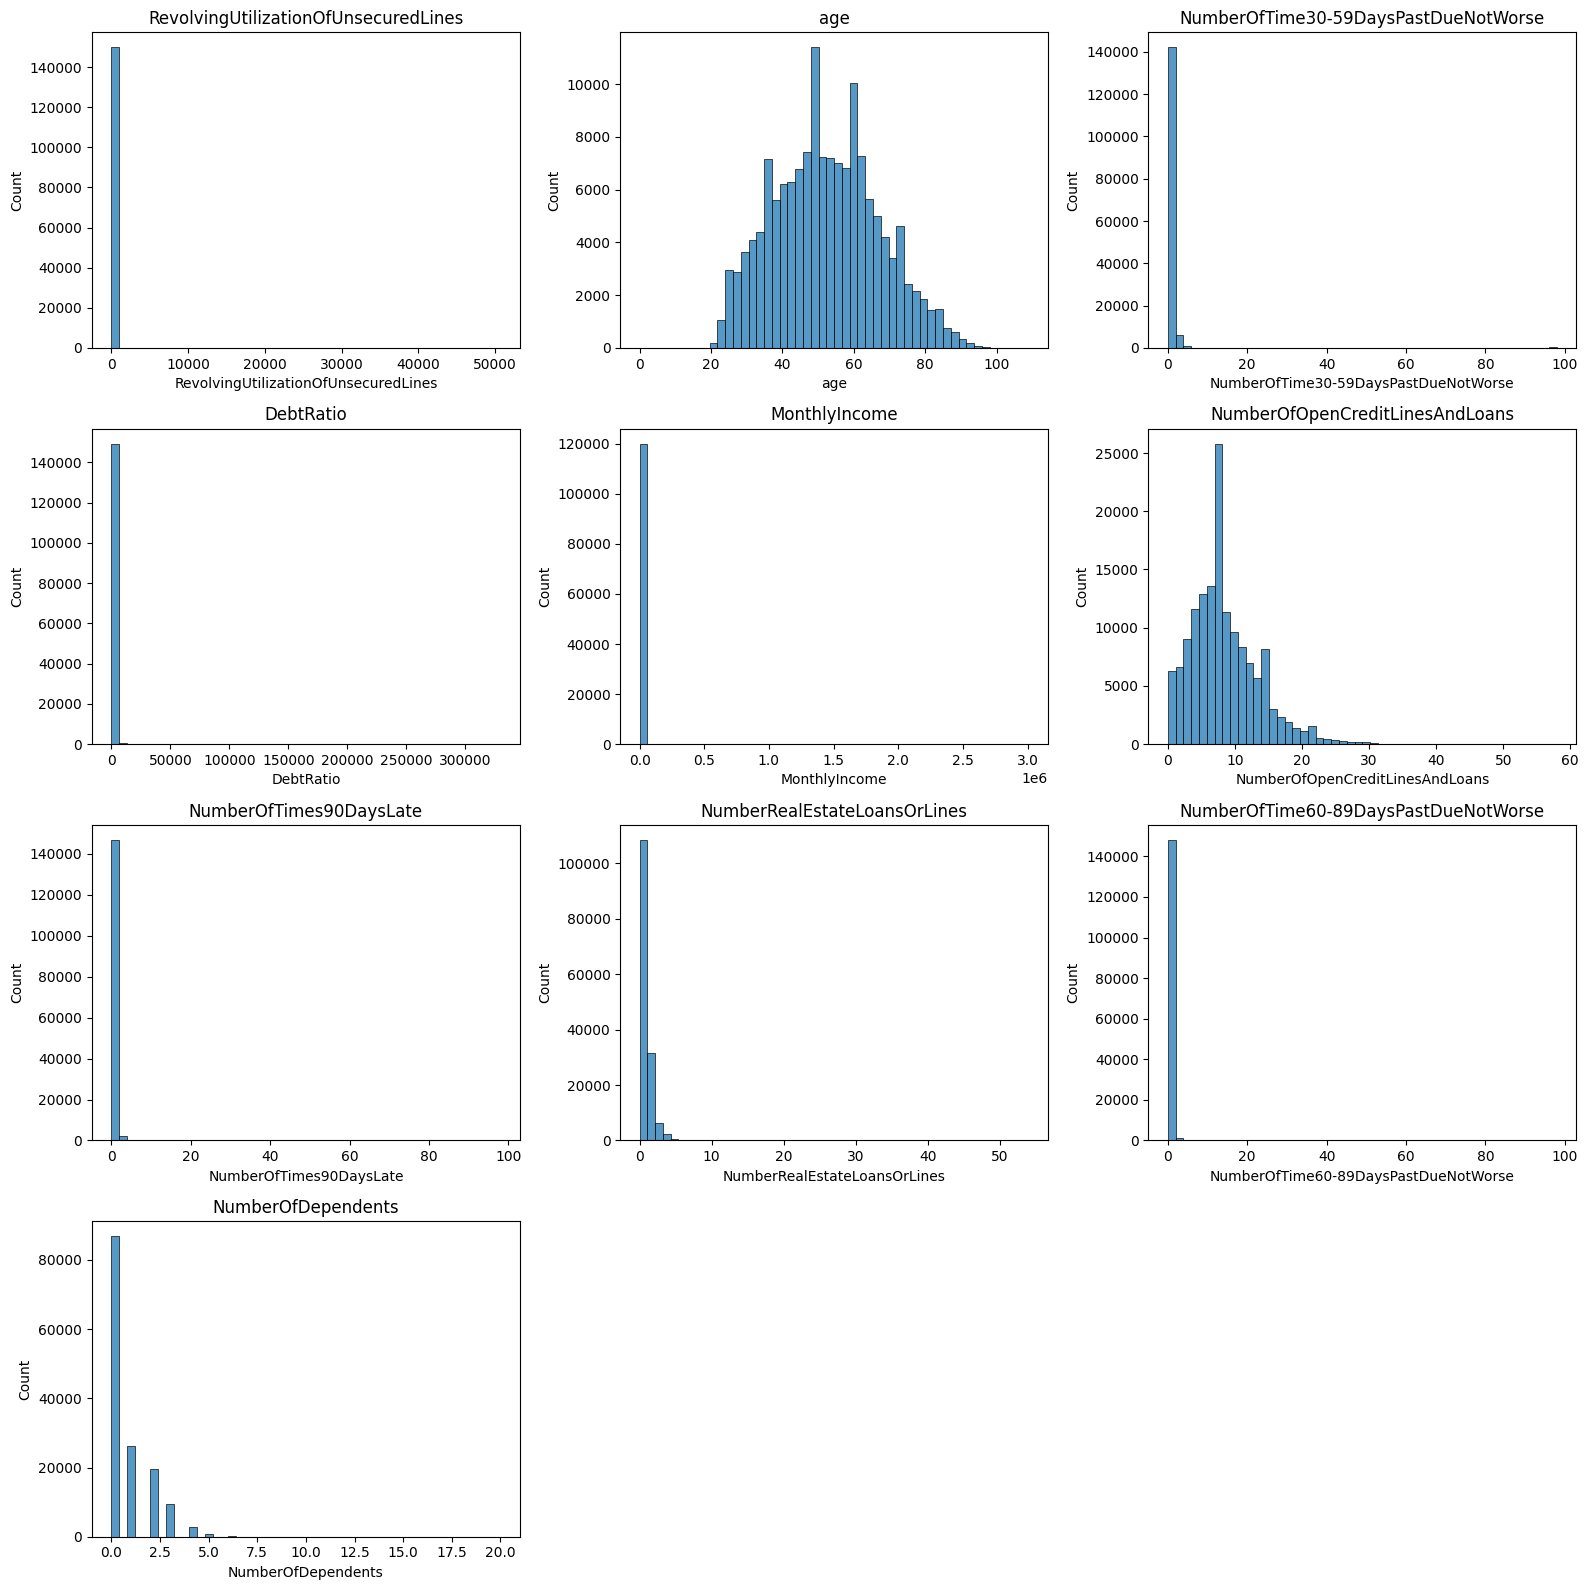

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Unnamed: 0')
numeric_cols.remove('SeriousDlqin2yrs')

num_grafs= len(numeric_cols) # qtd de graficos
plots_por_linha = 3
num_rows = (num_grafs + plots_por_linha - 1) // plots_por_linha

fig, axes = plt.subplots(num_rows, plots_por_linha, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  if i < len(axes):
    sns.histplot(data=df,
                 x=col,
                 ax=axes[i],
                 bins=50
    )
    axes[i].set_title(col)

# Removendo os vazios
for j in range(num_grafs, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Observando os histogramas das variáveis do dataset, nota-se que a maioria apresenta distribuição assimétrica à direita (assimetria positiva). A variável **'Age'** é a que mais se aproxima de uma distribuição normal. Além disso, como já mencionado anteriormente, a distribuição da coluna **'MonthlyIncome'** se destaca por estar em uma escala significativamente diferente das demais, com valores mais dispersos e presença de outliers. Além dela, a coluna **'DebtRatio'** e a **'RevolvingUtilizationOfUnsecuredLines'** também apresentam grande amplitude e valores extremos, indicando alta variabilidade e possível presença de outliers Enquanto os demais registros se concentram em faixas relativamente baixas.

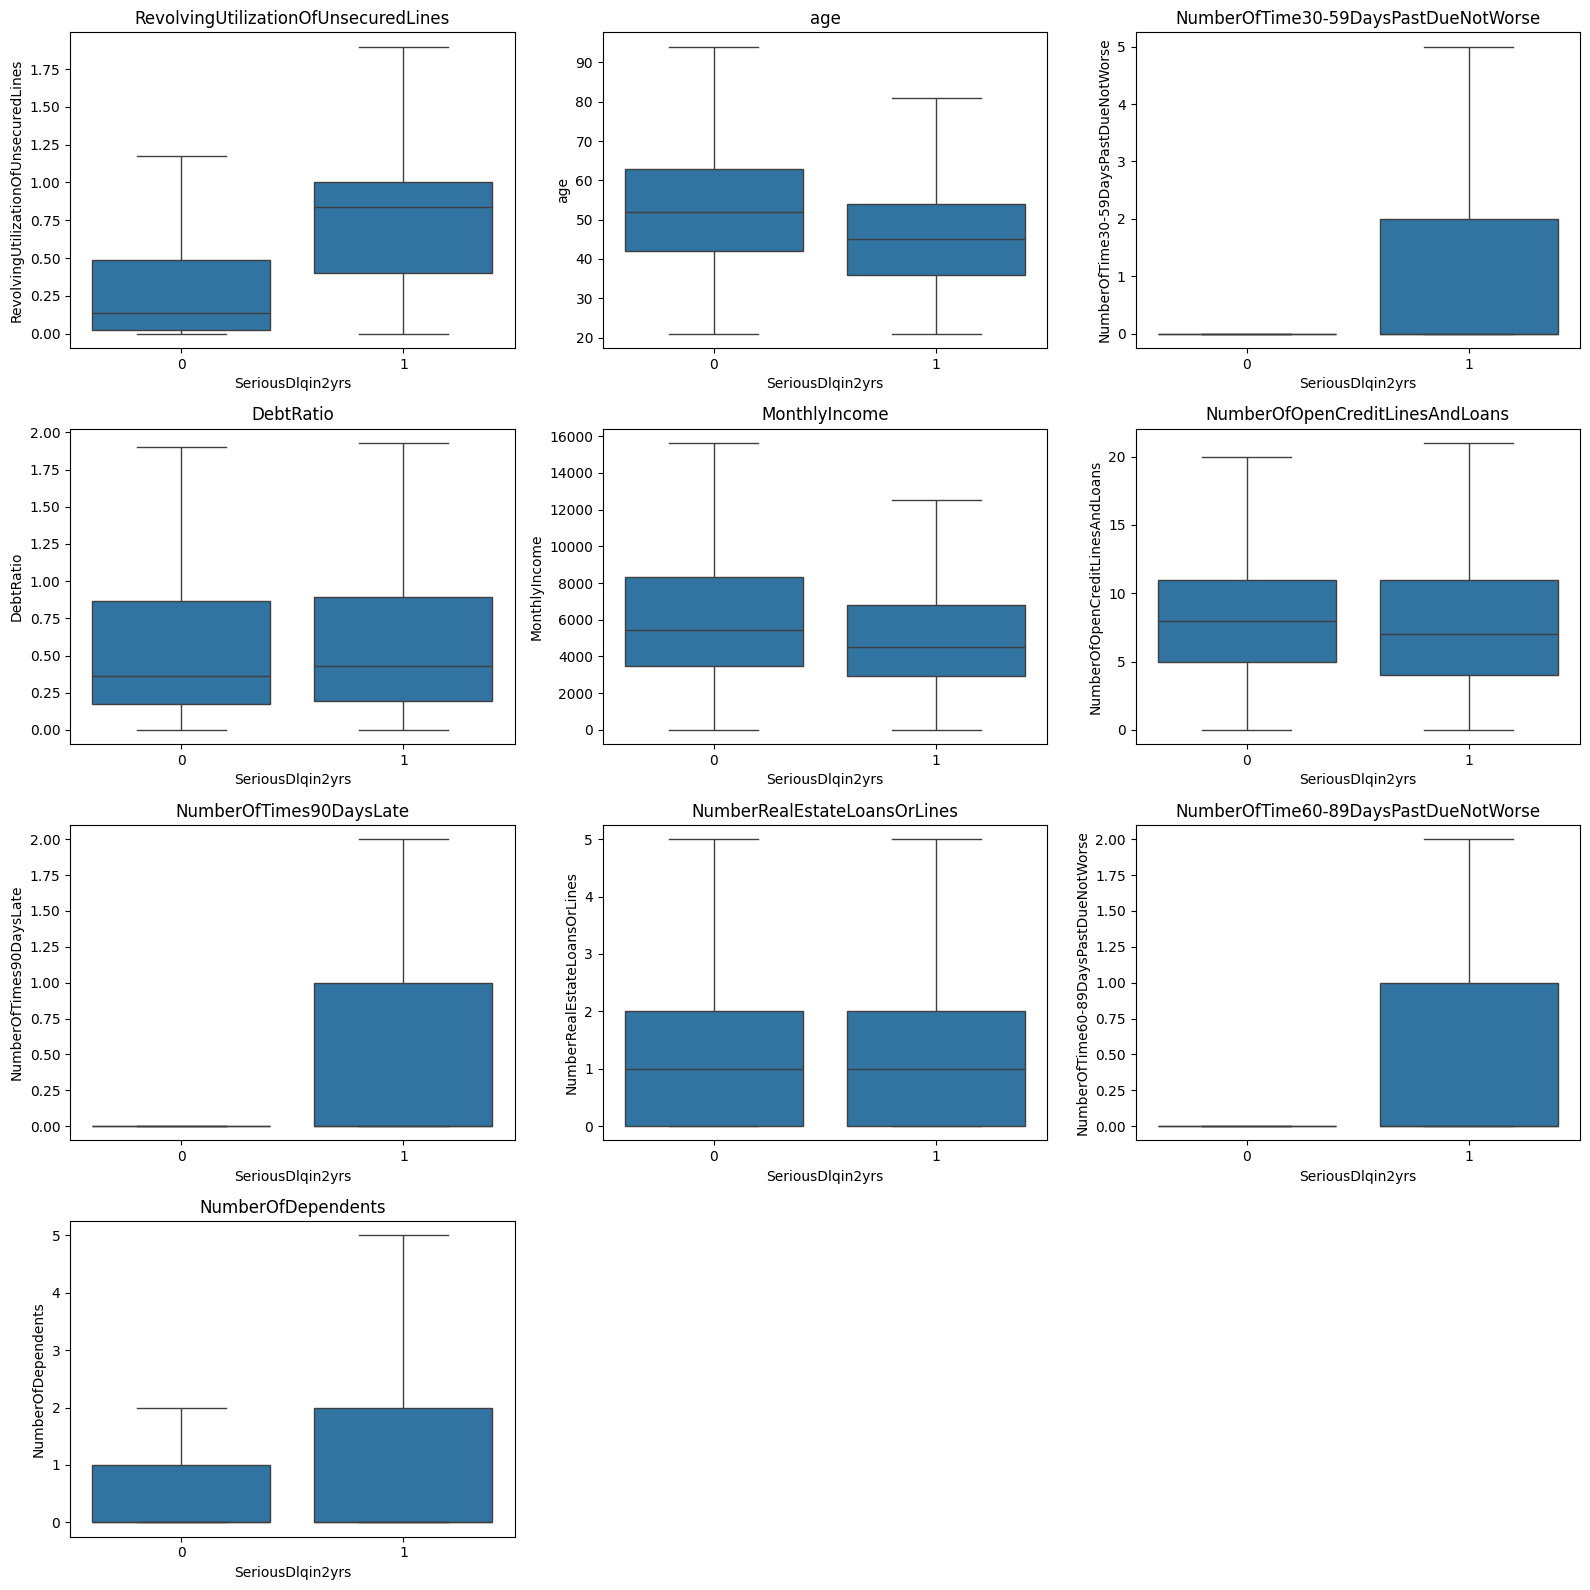

In [13]:
#avaliando a distribuição do target por variáveis de interesse

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
# transforma a matriz de eixos em uma lista

    sns.boxplot(
        data=df,
        x='SeriousDlqin2yrs',
        y=col,
        showfliers=False,
        ax=axes[i]
    )

    axes[i].set_title(col)

# removendo eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Os boxplots acima comparam a distribuição das variáveis entre clientes que apresentaram inadimplência grave (SeriousDlqin2yrs = 1) e aqueles que não apresentaram (SeriousDlqin2yrs = 0), com o objetivo de identificar possíveis diferenças entre os grupos.

O principal destaque observado é que as variáveis **'NumberOfTimes90DaysLate'**, **'NumberOfTime30-59DaysPastDueNotWorse'** e **'NumberOfTime60-89DaysPastDueNotWorse'**, todas referentes a atraso de pagamento. Assim, é possível concluir que os clientes que aprensentaram inadimplência grave, em geral, possuem maior frequência de atrasos em seus históricos, o que sugere que essas variávies tem grande potencial no modelo preditivo que será aplicado nesste trabalho.

Além disso, '**Monthlyincome'** **'RevolvingUtilizationOfUnsecuredLines'** e também possuem uma diferença relevante entre os dois grupos. Os clientes inadimplentes tendem a apresentar maior utilização do crédito disponível e menor renda mensal quando comparados aos demais clientes. Outro pontos de destaque é que os clientes inadimplentes são mais jovens.

Por outro lado, as variáveis **'DebtRatio'**,  mostra **'NumberOfOpenCreditLinesAndLoans'** e **'NumberRealEstateLoansOrLines'** apresentaram distribuições semelhantes entre os grupos.

<Axes: >

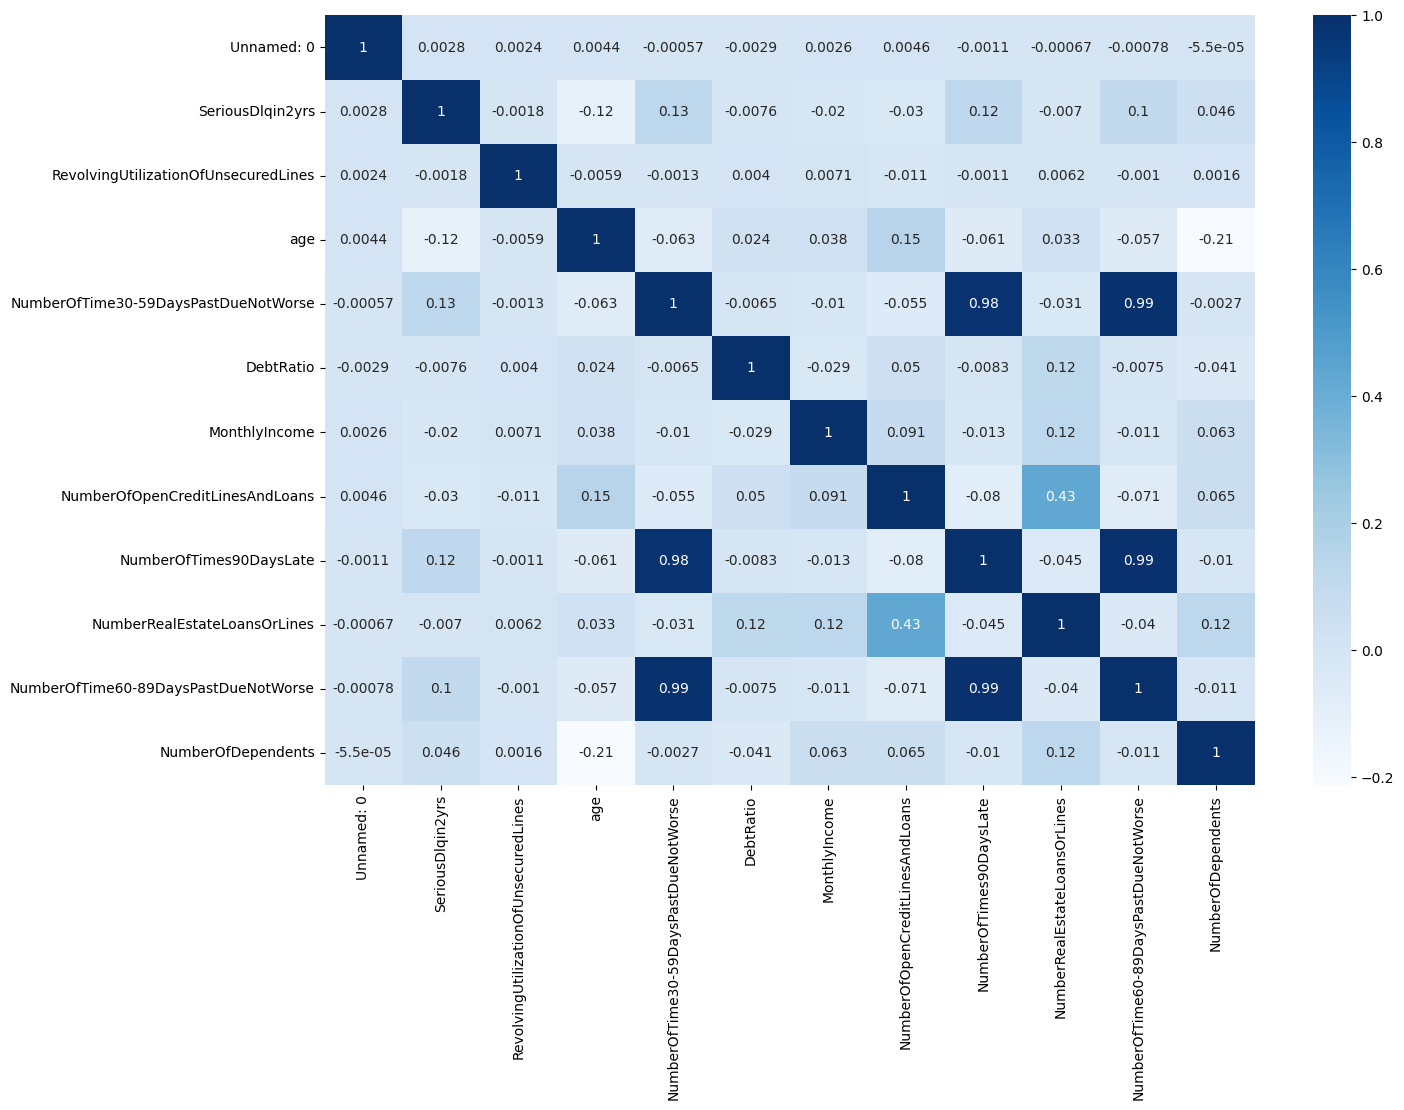

In [14]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot = True, cmap = 'Blues')

A matriz de correlação revelou uma forte correlação positiva entre as variáveis **'NumberOfTime30-59DaysPastDueNotWorse'**, **'NumberOfTimes90DaysLate'** e **'NumberOfTime60-89DaysPastDueNotWorse'**, com correlações superiores a 0,98. Como todas representam diferentes dias de atraso de pagamento, é possível que estejam abordando características parecidos na inadimplência dos clientes.

Além disso, a matriz de correlação reforça que quanto maior os atrasos anteriores, maior a chance de inadimpência e que quanto mais jovem maior a chance de inadimplência.


## 4.1 Síntese da análise exploratória

Como avaliado acima, o taget está desbalanceado, sendo 93,32% não inadimplentes e 6,68% inadimplentes. Além disso, foram encontrados 19,8% dos valores da coluna **'MonthlyIncome'** ausentes e 2,6% da coluna **'NumberOfDependents'**. Outro fato relevante é que algumas colunas apresentaram escalas muito diferentes: **'MonthlyIncome'** com valores até 3,008,750.00, **'DebtRatio'** com valores até 329,664.00 e **'RevolvingUtilizationcom'** valores até 50,708.00.

Como o dataset em questão possui outliers, os modelos baseados em árvores de decisão como Random Forest e XGBoost costumam funcionar melhor.
Com base na EDA a estégia de pré-processamento irá incluir o tratamento de valores faltantes e será necessário considerar métricas adequadas para classes desbalanceadas.


# 5. Preparação dos dados e divisão treino/teste

In [15]:
#separando o dataset em target e feature
TARGET = "SeriousDlqin2yrs"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ['Unnamed: 0']
DATE_COLUMN = None
DROP_COLUMNS = []

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)


features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: SeriousDlqin2yrs
Número de features: 10
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


Como indicado acima, o modelo desenvolvido é de classificação, o target é a coluna **'SeriousDlqin2yrs'** há 10 features no dataset.

In [16]:
#Separando as features (X) e o target (y)
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

# Dividindo o conjunto em Treino (80%) e Teste (20%) com estratificação
# A estratificação garante que a proporção de inadimplentes seja idêntica no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"\nProporção do target no treino:\n{y_train.value_counts(normalize=True)}")

X_train: (120000, 11), y_train: (120000,)
X_test: (30000, 11), y_test: (30000,)

Proporção do target no treino:
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


O dataset foi separado na proporção 80/20 utilizando o parâmetro **stratify=y**. Como a classe alvo é muito desbalanceada, a estratificação é importante para evitar que o conjunto de teste ou treino fique sem amostras suficientes da classe 1 (inadimplentes). Além disso, não foi realizada nenhuma transformação de dados ou tratamento de nulos foi realizado antes desta divisão para garantir a total prevenção contra o vazamento de dados (*data leakage*).


### 5.1 Justificativa da divisão

A escolha de como dividir os dados foi feita pensando nas características da nossa base de dados e como temos uma base muito grande (150 mil linhas), separar uma parte para treino e outra para teste é suficiente e não precisamos de divisão por tempo porque os dados não estão organizados em ordem cronológica.

Escolhi deixar 80% dos dados para o modelo treino e 20% para testar. Essa quantidade é mais do que suficiente para termos um teste confiável.

Para esse dataset foi necessário realizar a estratificação, uma vez que ele é muito desequilibrado e ao **stratify=y** é possível garantir que a mesma proporção de inadimplentes fique guardada tanto no treino quanto no teste, evitando que o teste fique sem exemplos de devedores.

Para prevenir o vazamento de dados, a divisão foi feita antes de tratar os valores nulos ou mexer na escala dos dados. Assim, garantimos que o modelo não tenha acesso a nenhuma informação do grupo de teste na hora de treinar.

# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [17]:
#Definindo os passos do nosso pipeline de pré-processamento
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Como já avaliamos anteriormente, o dataset possui apenas variáveis númericas e partimos direto para o tratamento dos dados. Para tal, foi usado o Pipeline do scikit-learn garante que o preenchimento de nulos e a padronização sejam calculados usando apenas as estatísticas do grupo de treino e aplicados de forma limpa no teste, eliminando qualquer risco de vazamento de dados.

 Assim, esse pipeline está sendo utilizado para realizar apenas duas transformações de maneira automática. A primeira transformação **SimpleImputer(strategy='median')** está tratando valores ausentes de renda (**'MonthlyIncome'**) e dependentes (**'NumberOfDependents'**) e os preenchendo com a mediana. A mediana foi escolhida em preferência a média porque foi avaliado durrante a análise exploratória que o dataset possui outliers que distorcem a média.

Já a segunda transformação, **StandardScaler()**, está colocando todas as variáveis na mesma escala, com média 0 e desvio padrão 1. O objetivo dessa transformação é impedir que o modelo de um peso maior para uma variável diferente só porque ela possui um número maior. Exemplo: um salário na casa dos milhões não pode ser mais importante que uma idade na casa das dezenas apenas porque o números é maior.

# 7. Baseline e modelos candidatos



In [18]:
#Criando o Pipeline completo junto com o Modelo Baseline usando o DummyClassifier
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=SEED))
])

#Treinando o Baseline
baseline_pipeline.fit(X_train, y_train)

#Fazendo previsões nos dados de teste
y_pred_baseline = baseline_pipeline.predict(X_test)
y_proba_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

#Calculando as métricas do Baseline
print("=== RESULTADOS DO MODELO BASELINE ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score (Weighted): {f1_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_baseline):.4f}")

=== RESULTADOS DO MODELO BASELINE ===
Acurácia: 0.9332
F1-Score (Weighted): 0.9009
ROC AUC: 0.5000


 O Baseline escolhido foi um **DummyClassifier**, um modelo simples que "chuta" que todo mundo vai pagar em dia, uma vez que essa é a resposta mais frequente, que serve para nos dar uma base de comparação. Assim, vemos que em dados desequilibrados, olhar só para a acurácia (9,323%) pode nos enganar. O resultado real dele na métrica de separação (ROC AUC) é de 0.50, o que equivale a jogar uma moeda para o alto. Assim, é esperado superar esse resultado em todos os casos de modelo candidato.

In [19]:
# Criando o dicionário de modelos candidatos
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=SEED, max_depth=10, n_jobs=-1))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "DecisionTree": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=SEED, max_depth=10))
    ])
}

# Treinando todos os modelos candidatos
results = {}
for name, pipe in candidates.items():
    print(f"Treinando {name}...")
    pipe.fit(X_train, y_train)
    # Pegando as probabilidades para calcular o ROC AUC
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = roc_auc_score(y_test, y_proba)

# Exibindo a tabela final de comparação
print("\n=== COMPARAÇÃO DE DESEMPENHO (ROC AUC) ===")
print(f"Baseline (Dummy):       {roc_auc_score(y_test, y_proba_baseline):.4f}")
for name, score in results.items():
    print(f"{name:<20}: {score:.4f}")

Treinando LogisticRegression...
Treinando RandomForest...
Treinando KNN...
Treinando DecisionTree...

=== COMPARAÇÃO DE DESEMPENHO (ROC AUC) ===
Baseline (Dummy):       0.5000
LogisticRegression  : 0.7144
RandomForest        : 0.8672
KNN                 : 0.6609
DecisionTree        : 0.8262


### 7.1 Justificativa dos modelos

Para este projeto, as escolhas dos modelos foram pensadas de acordo com o nosso problema de risco de crédito. Além disso, todos os modelos candidatos usam o mesmo Pipeline de preparação, permitindo uma comparação justa.

O uso do **DummyClassifier** como baseline pode ser considerado coerente. Como nossa base é muito desbalanceada, onde quase todos os clientes pagam em dia, ele serve para provar que uma acurácia alta pode ser enganosa. Ele nos dá um parâmentro de comparação (ROC AUC de 0.50) que qualquer modelo real precisa superar.

Os modelos escolhidos são adequados ao dataset que temos, onde temos um formato de tabela e um volume grande de dados. Considerando esse cenário, a **LogisticRegression** e a **DecisionTree** rodam muito rápido. Enquanto isso, o **RandomForest** exige mais capacidade de processamento do computador por criar várias árvores, mas funciona bem para lidar com o volume de dados e encontrar padrões difíceis. Por fim, o **KNN** analisa a proximidade entre os perfis dos clientes, o que faz sentido para agrupar comportamentos parecidos.

Alguns desses modelos precisam de cuidados especifícios e tratamento de escala. A **LogisticRegression** e o **KNN** são baseados em cálculos de distância matemática, por isso eles exigem obrigatoriamente que os dados estejam na mesma escala e por este motivo, foi realizado o tratamento de padronização (**StandardScaler** no Pipeline). Já os modelos de árvore, **DecisionTree** e **RandomForest** não sofrem com a escala dos dados. No entanto, todos os modelos se beneficiam do preenchimento de valores nulos.

 Os Modelos como **LogisticRegressio** e **DecisionTree** são ótimos para a questão da interpretabilidade, uma vez que são mais fáceis de explicar. Já o **RandomForest** é um modelo mais complexo por combinar centenas de árvores ao mesmo tempo, mas entrega muito mais caminhos e precisão. Quanto ao tempo, por estarmos usando o ambiente gratuito do Google Colab, limitamos o tamanho máximo das árvores (max_depth=10) para o código rodar rápido e não travar o sistema.

# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [20]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


NameError: name 'baseline' is not defined

## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> _Preencha aqui._


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Preencha aqui._


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")
